Estrellas variables
==

Alumno
---
Pedro G. Villegas

Docentes
---
J.P. Calderón & R. Gamen

Resumen
---
La estrella $\delta$ Cephei es el prototipo de las 
*variables Cefeidas*. Es un tipo de estrella que pulsa
radialmente, variando tanto su radio como su temperatura, lo que
produce cambios en el brillo, con un período y amplitud bien
definidos. Hay una fuerte relación entre la luminosidad y el
período de pulsación de las variables cefeidas, lo que las
convierte en un importante indicador de distancias tanto
galácticas como extragalácticas.


Referencias
---
* [Práctica 09 (overleaf)](https://www.overleaf.com/read/bqjcfkmvfmsw)
* Datos de $\delta$cephei: https://iopscience.iop.org/article/10.1088/0004-637X/794/1/80/pdf
* Base de datos OGLE: http://www.astrouw.edu.pl/ogle

---

# 1. La curva de luz de $\delta$ cephei

In [1]:
from matplotlib import pyplot as plt
import pandas as pd

from astropy.timeseries import LombScargle
import numpy as np

In [2]:
#url_data = "https://iopscience.iop.org/0004-637X/794/1/80/suppdata/apj500194t4_ascii.txt"
url_data = "apj500194t4_ascii.txt"

data = pd.read_csv ( url_data, sep = "\t", skiprows = 2, skip_blank_lines = True, header = 0, na_values = np.nan )

In [3]:
data

,HJD,Phase,V-mag,error,HJD.1,Phase.1,U - B,error.1,HJD.2,Phase.2,...,error.2,HJD.3,Phase.3,V - R,error.3,HJD.4,Phase.4,R - I,error.4,Unnamed: 20
0,2.454438e+06,-0.2357,4.3136,0.0026,2.454438e+06,-0.2362,0.6518,0.0060,2.454438e+06,-0.2360,...,0.0062,2.454624e+06,0.4846,0.8475,0.0133,2.454624e+06,0.4846,0.4449,0.0182,NaN
1,2.454440e+06,0.1365,3.6690,0.0056,2.454440e+06,0.1367,0.3887,0.0216,2.454440e+06,0.1365,...,0.0104,2.454625e+06,-0.3299,0.8906,0.0133,2.454625e+06,-0.3298,0.4568,0.0213,NaN
2,2.454441e+06,0.3215,3.9369,0.0015,2.454441e+06,0.3215,0.5173,0.0081,2.454441e+06,0.3215,...,0.0058,2.454626e+06,-0.1431,0.8115,0.0306,2.454626e+06,-0.1431,0.3999,0.0298,NaN
3,2.454448e+06,-0.3752,4.2614,0.0029,2.454448e+06,-0.3750,0.6512,0.0043,2.454448e+06,-0.3752,...,0.0035,2.454627e+06,0.0416,0.6316,0.1148,2.454627e+06,0.0416,0.3114,0.1183,NaN
4,2.454450e+06,-0.0024,3.4627,0.0206,2.454450e+06,-0.0025,0.3408,0.0429,2.454450e+06,-0.0024,...,0.0270,2.454629e+06,0.4133,0.8242,0.0368,2.454629e+06,0.4134,0.4223,0.0388,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,2.455920e+06,-0.0582,3.5778,0.0056,2.455923e+06,-0.4965,0.5951,0.0057,2.455920e+06,-0.0582,...,0.0056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,2.455923e+06,-0.4964,4.1270,0.0054,2.455927e+06,0.2462,0.4516,0.0113,2.455923e+06,-0.4964,...,0.0065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,2.455927e+06,0.2462,3.8209,0.0048,2.455928e+06,0.4328,0.5737,0.0143,2.455927e+06,0.2462,...,0.0083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108,2.455928e+06,0.4328,4.0375,0.0060,2.455932e+06,0.1757,0.3997,0.0097,2.455928e+06,0.4328,...,0.0090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


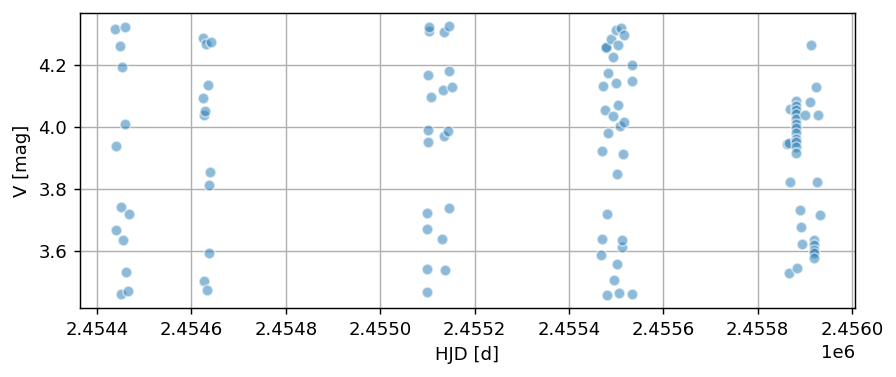

In [4]:
%matplotlib inline

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.scatter ( 'HJD', 'V-mag', data = data, color = "tab:blue", edgecolor = "white", alpha = 0.5, zorder = 10 )

ax.set_xlabel ( 'HJD [d]' )
ax.set_ylabel ( 'V [mag]') 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

In [5]:
t = data['HJD']
y = data['V-mag']
dy = data['error']

ls = LombScargle ( t, y, dy )

frequency, power = ls.autopower ( minimum_frequency = 0.01, maximum_frequency = 10 )

period = 1./frequency 
best_period = 1./frequency[np.argmax(power)]  
phase = (data['HJD'] / best_period) % 1  

print ( "Mejor período: %.3f (días)" % (best_period) )

Mejor período: 5.368 (días)


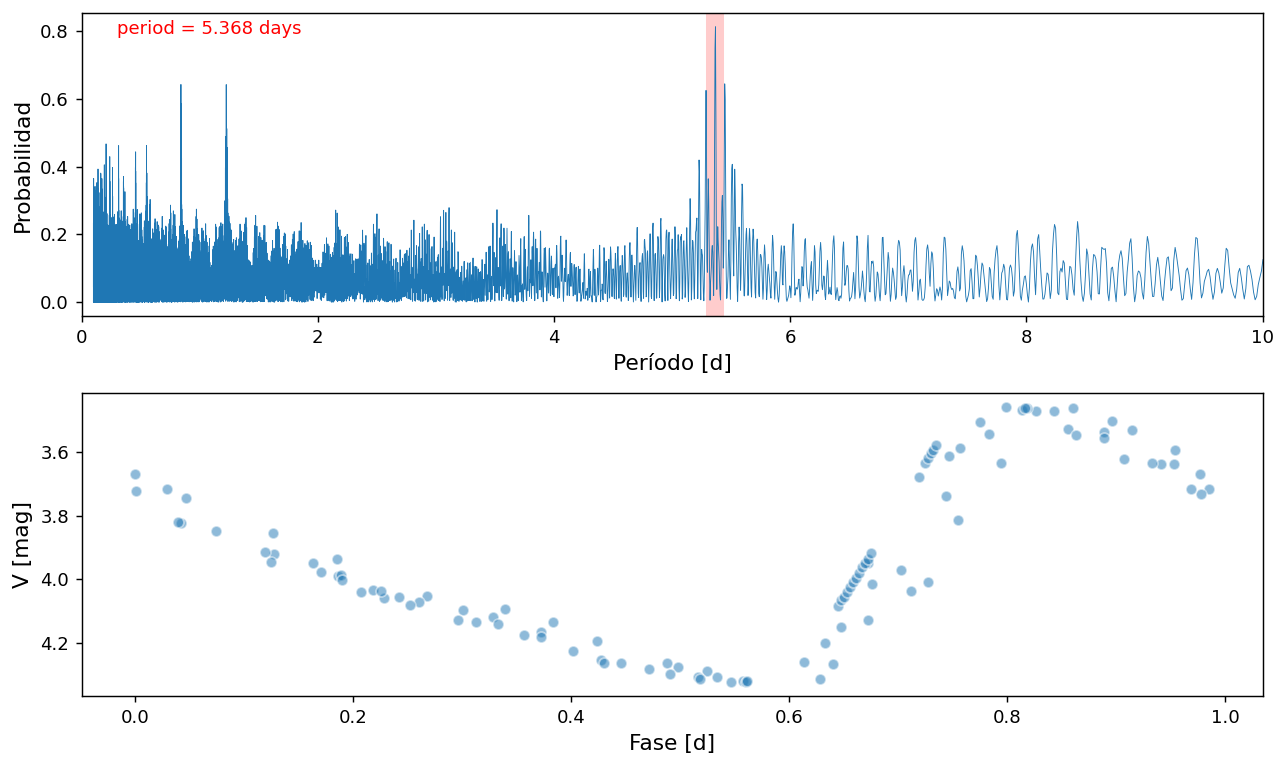

In [6]:
%matplotlib inline

fig, (ax0, ax1) = plt.subplots ( ncols = 1, nrows = 2, figsize = (10, 6), dpi = 130 )

ax0.plot ( period, power, lw = 0.5 )
ax0.axvline( best_period, color = 'red', alpha = 0.2, linewidth = 10, zorder = -10 )
ax0.text ( 0.03, 0.93,'period = {:.3f} days'.format( best_period ), 
         transform = ax0.transAxes, color = 'red', zorder = -10 )
   
ax0.set_xlabel ( 'Período [d]', size=12 )
ax0.set_ylabel ( 'Probabilidad', size=12 )    
ax0.set_xlim ( 0,10)

ax1.scatter ( phase, data['V-mag'], color = "tab:blue", edgecolor = "white", alpha = 0.5, zorder = 10 )
ax1.invert_yaxis()

ax1.set_xlabel ( 'Fase [d]', size=12 )
ax1.set_ylabel ( 'V [mag]', size=12) 

fig.tight_layout()
plt.show()

# 1.1 Calcular la distancia a $\delta$ Cephei

In [7]:
from astroquery.simbad import Simbad

result_table = Simbad.query_object("delta cephei")
print(result_table)

 MAIN_ID        RA           DEC      ... COO_WAVELENGTH     COO_BIBCODE    
             "h:m:s"       "d:m:s"    ...                                   
--------- ------------- ------------- ... -------------- -------------------
* del Cep 22 29 10.2650 +58 24 54.713 ...              O 2007A&A...474..653V


In [8]:
Simbad.list_votable_fields()

--NOTES--

1. The parameter filtername must correspond to an existing filter. Filters include: B,V,R,I,J,K.  They are checked by SIMBAD but not astroquery.simbad

2. Fields beginning with rvz display the data as it is in the database. Fields beginning with rv force the display as a radial velocity. Fields beginning with z force the display as a redshift

3. For each measurement catalog, the VOTable contains all fields of the first measurement. When applicable, the first measurement is the mean one. 

Available VOTABLE fields:

bibcodelist(y1-y2)
biblio
cel
cl.g
coo(opt)
coo_bibcode
coo_err_angle
coo_err_maja
coo_err_mina
coo_qual
coo_wavelength
coordinates
dec(opt)
dec_prec
diameter
dim
dim_angle
dim_bibcode
dim_incl
dim_majaxis
dim_minaxis
dim_qual
dim_wavelength
dimensions
distance
distance_result
einstein
fe_h
flux(filtername)
flux_bibcode(filtername)
flux_error(filtername)
flux_name(filtername)
flux_qual(filtername)
flux_system(filtername)
flux_unit(filtername)
fluxdata(filtername)

In [9]:
s = Simbad()
s.get_votable_fields()

['main_id', 'coordinates']

In [10]:
s.add_votable_fields('fluxdata(V)')
s.get_votable_fields()

['main_id', 'coordinates', 'fluxdata(V)']

In [11]:
result = s.query_object('delta cephei')

In [12]:
print(result['FLUX_V'][0])

3.75


In [13]:
def PL(p): #período luminosidad
    """https://ui.adsabs.harvard.edu/abs/2010OAP....23..119T/"""
    return (-1.304) - (2.786) * np.log10(p)

print ("Magnitud absoluta %.2f [V-mag]" %(PL (best_period)))

Magnitud absoluta -3.34 [V-mag]


In [14]:
def MD(m, M, A): #módulo de distancia
    """ v - A_v = M_v + 5*log(d) - 5"""
    return 10**((( m - M - A) + 5)/5)

print ( "Distancia: %.2f [pc]" %(MD ( result['FLUX_V'][0], PL (best_period), 0 )))

Distancia: 261.48 [pc]


In [15]:
s.add_votable_fields ( 'parallax' )
result = s.query_object('delta cephei')

In [16]:
print ( "Distancia (SIMBAD): %.2f [pc]" %((1./result['PLX_VALUE'][0])*1000.))

Distancia (SIMBAD): 265.25 [pc]


# 2. Distancia a LMC y SMC

* http://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/

* http://www.astrouw.edu.pl/ogle/ogle4/OCVS/smc/

In [17]:
from matplotlib import pyplot as plt
import pandas as pd

from astropy.timeseries import LombScargle
import numpy as np

## 2.1 Cefeida clásica (LMC)

In [18]:
Nstar = "001"

data_url = "http://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/phot/I/OGLE-LMC-CEP-0" + Nstar + ".dat"
data = pd.read_csv ( data_url, sep = " ", header = None, names = [ "HJD", "mag", "mag_error"] )

In [19]:
data

,HJD,mag,mag_error
0,5262.50650,17.639,0.018
1,5264.50830,17.816,0.017
2,5265.59327,17.610,0.018
3,5266.50460,17.590,0.019
4,5267.50409,17.687,0.019
...,...,...,...
396,7458.59979,17.868,0.016
397,7465.50239,17.588,0.013
398,7471.53717,17.943,0.030
399,7475.51366,17.941,0.017


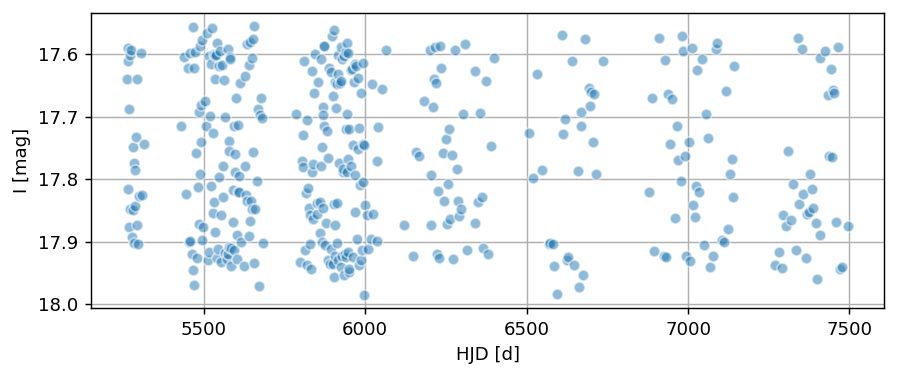

In [20]:
%matplotlib inline

fig, ax = plt.subplots( figsize = (7,3), dpi = 130 )

ax.scatter ( 'HJD', 'mag', data = data, color = "tab:blue", edgecolor = "white", alpha = 0.5, zorder = 10 )
ax.invert_yaxis()

ax.set_xlabel ( 'HJD [d]' )
ax.set_ylabel ( 'I [mag]') 

ax.grid ( True ) 
fig.tight_layout()
plt.show()

In [21]:
t = data['HJD']
y = data['mag']
dy = data['mag_error']

ls = LombScargle ( t, y, dy )

frequency, power = ls.autopower ( minimum_frequency = 0.01, maximum_frequency = 20 )

period = 1./frequency 
best_period = 1./frequency[np.argmax(power)]  
phase = (data['HJD'] / best_period) % 1  

print("Mejor periodo: {:.3f} (días)".format(best_period))

Mejor periodo: 0.307 (días)


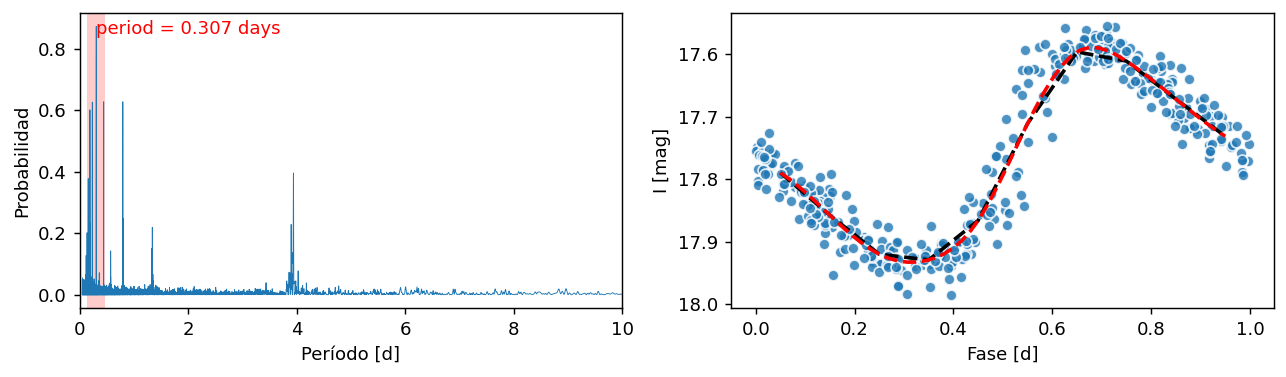

In [22]:
from scipy.stats import binned_statistic
from scipy.interpolate import make_interp_spline, BSpline

bin_means, bin_edges, binnumber = binned_statistic (
    phase.values, data['mag'].values, statistic='mean', bins = 10, range = [0,1] )
bin_width = (bin_edges[1] - bin_edges[0])
bin_centers = bin_edges[1:] - bin_width/2

X = np.linspace( bin_centers[0], bin_centers[-1], 50) 
Y =  make_interp_spline ( bin_centers , bin_means, k = 3 )(X)  # type: BSpline

%matplotlib inline

fig, (ax0, ax1) = plt.subplots ( ncols = 2, nrows = 1, figsize = (10, 3), dpi = 130 )

ax0.plot ( period, power, lw = 0.5 )
ax0.axvline( best_period, color = 'red', alpha = 0.2, linewidth = 10, zorder = -10 )
ax0.text ( 0.03, 0.93,'period = {:.3f} days'.format( best_period ), 
         transform = ax0.transAxes, color = 'red' )
   
ax0.set_xlabel ( 'Período [d]' )
ax0.set_ylabel ( 'Probabilidad' )    
ax0.set_xlim ( 0,10)

ax1.scatter ( phase, data['mag'], color = "tab:blue", edgecolor = "white", alpha = 0.8, zorder = 9 )
ax1.plot ( bin_centers, bin_means, color = "black", linewidth = 2.0, linestyle = "dashed", zorder = 10 )
ax1.plot ( X, Y, color = "red", linewidth = 2.0, linestyle = "dashed", zorder = 10 )

ax1.invert_yaxis()

ax1.set_xlabel ( 'Fase [d]' )
ax1.set_ylabel ( 'I [mag]') 

fig.tight_layout()
plt.show()

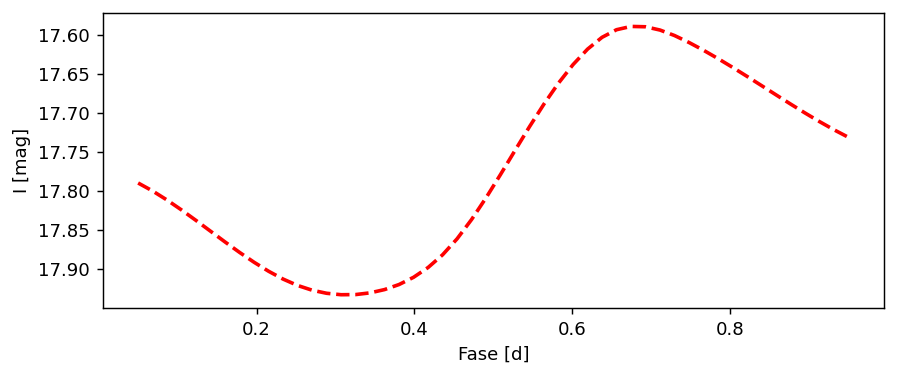

In [23]:
%matplotlib inline

fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (7, 3), dpi = 130 )

ax.plot ( X, Y, color = "red", linewidth = 2.0, linestyle = "dashed", zorder = 10 )
ax.invert_yaxis()

ax.set_xlabel ( 'Fase [d]' )
ax.set_ylabel ( 'I [mag]') 

fig.tight_layout()
plt.show()

## 2.2 Obtengo el período de al menos 10 cefeidas (LMC)

In [24]:
'''El procedimiento consiste en lo siguiente:
    - Con los datos que importo de OGLE (mag ap vs HJD) calculo el período de variación de brillo (LombScargle)
    - Con best_period voy a la relación período luminosidad para ese cúmulo y calculo la magnitud absoluta
    - Con los datos de OGLE nuevamente, calculo la magnitud aparente media
    - Ya con Mag_Abs y Mag_Mean, calculamos la distancia'''

# (Calcular la magnitud aparente media == mag_mean)
mag_mean = data['mag'].mean()
print('Magnitud aparente media = ', mag_mean)

Magnitud aparente media =  17.769448877805488


In [25]:
p = best_period # Calculado en el grupo anterior, es la misma estrella supongo

def Mabs_LMC(p):
    """ Datos extraídos de: https://ui.adsabs.harvard.edu/abs/2004MNRAS.349.1130N/abstract """
    a = -3.319 # \pm 0.098
    b = -1.406 # \pm 0.108
    return a * np.log10(p) + b

Mabs = Mabs_LMC(p)
print('Magnitud absoluta = ', Mabs)

Magnitud absoluta =  0.297020773559467


In [26]:
def MD(m, M, A): #módulo de distancia
    """ v - A_v = M_v + 5*log(d) - 5"""
    return 10**((( m - M - A) + 5)/5)

MD ( mag_mean, Mabs, 0.26  ) * 0.001 # en kpc

# Exceso de color: https://ui.adsabs.harvard.edu/abs/2020ApJ...890..137T/abstract

27.700373238750487

In [27]:
distance = ((MD ( mag_mean, Mabs, 0.26 ) * 0.001).mean())
distance_std = ((MD ( mag_mean, Mabs, 0.26 ) * 0.001).std())

In [28]:
print ( "Distancia promedio a LMC: %.3f kpc $\pm$ %.3f" %(distance, distance_std) )

Distancia promedio a LMC: 27.700 kpc $\pm$ 0.000


In [29]:
                       ################ LOOP LMC ################
'''El procedimiento consiste en lo siguiente:
    - Con los datos que importo de OGLE (mag ap vs HJD) calculo el período de variación de brillo (LombScargle)
    - Con best_period voy a la relación período luminosidad para ese cúmulo y calculo la magnitud absoluta
    - Con los datos de OGLE nuevamente, calculo la magnitud aparente media
    - Ya con Mag_Abs y Mag_Mean, calculamos la distancia'''

import pandas as pd

# ·--·--·--·--·--·--·--·--·--·--·--·-- Funciones ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
def Mabs_LMC(p):
    """ Datos extraídos de: https://ui.adsabs.harvard.edu/abs/2004MNRAS.349.1130N/abstract """
    a = -3.319 # \pm 0.098
    b = -1.406 # \pm 0.108
    return a * np.log10(p) + b

def MD(m, M, A): #módulo de distancia
    """ v - A_v = M_v + 5*log(d) - 5"""
    return 10**((( m - M - A) + 5)/5)
# Exceso de color: https://ui.adsabs.harvard.edu/abs/2020ApJ...890..137T/abstract
# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
Nstars = 10
CefeidasLMC = pd.DataFrame(columns = [ 'Star', 'Period', 'mag_mean', 'Mabs', 'Dist'])

for i in range(Nstars):
    Nstar = i + 40
    
    data_url = "http://www.astrouw.edu.pl/ogle/ogle4/OCVS/lmc/cep/phot/I/OGLE-LMC-CEP-" + str("%04d" %Nstar) + ".dat"
#    print (data_url)
    
    data = pd.read_csv ( data_url, sep = " ", header = None, names = ["HJD", "mag", "mag_error"] )
    t = data['HJD']
    y = data['mag']
    dy = data['mag_error']

    ls = LombScargle ( t, y, dy )
    frequency, power = ls.autopower ( minimum_frequency = 0.01, maximum_frequency = 20 )
    period = 1./frequency
    
    best_period = 1./frequency[np.argmax(power)]
    mag_mean = data['mag'].mean()
    Mabs = Mabs_LMC(best_period)
    dist = MD ( mag_mean, Mabs, 0.26  ) * 0.001 # en kpc
    Identificador = "OGLE-LMC-CEP-" + str("%04d" %Nstar)
    CefeidasLMC.loc[i] = [Identificador, best_period, mag_mean, Mabs, dist]

    print('Procesando estrella', Nstar)
#    print('Estrella = ', Nstar)
#    print('Período=', best_period, '// mag media=', mag_mean, '// Mabs=', Mabs, '// Distancia=', dist)
print('Distancia media = ', CefeidasLMC['Dist'].mean())

Procesando estrella 40
Procesando estrella 41
Procesando estrella 42
Procesando estrella 43
Procesando estrella 44
Procesando estrella 45
Procesando estrella 46
Procesando estrella 47
Procesando estrella 48
Procesando estrella 49
Distancia media =  41.572584598410266


In [30]:
CefeidasLMC

,Star,Period,mag_mean,Mabs,Dist
0,OGLE-LMC-CEP-0040,5.163955,14.680230,-3.772389,43.503455
1,OGLE-LMC-CEP-0041,2.910288,15.526833,-2.945804,43.906340
2,OGLE-LMC-CEP-0042,2.577159,15.682119,-2.770578,43.505020
3,OGLE-LMC-CEP-0043,3.148588,14.823181,-3.059247,33.456880
4,OGLE-LMC-CEP-0044,4.035403,14.950546,-3.416939,41.830882
5,OGLE-LMC-CEP-0045,1.866859,16.153790,-2.305819,43.643731
6,OGLE-LMC-CEP-0046,8.846377,13.967887,-4.548314,44.796108
7,OGLE-LMC-CEP-0047,2.071450,15.277547,-2.455715,31.235786
8,OGLE-LMC-CEP-0048,5.548007,14.491719,-3.875791,41.831360
9,OGLE-LMC-CEP-0049,3.849295,15.318063,-3.348880,48.016286


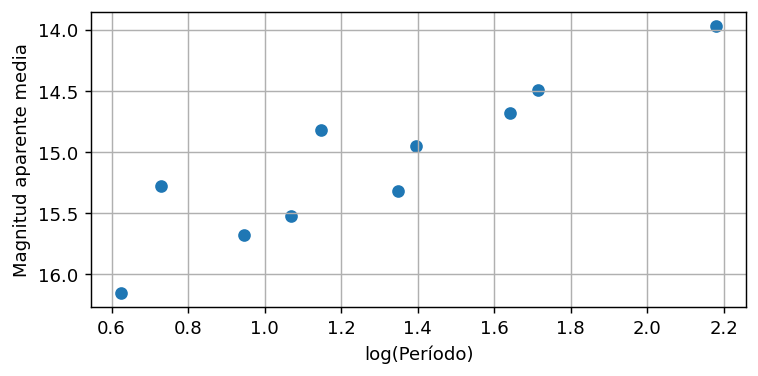

In [31]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6.5, 3), dpi = 130 )

ax.scatter ( np.log(CefeidasLMC['Period']), 'mag_mean', data = CefeidasLMC)
ax.grid(True)
ax.xaxis.grid(which='minor')

ax.set_xlabel('log(Período)')
ax.set_ylabel('Magnitud aparente media')
ax.invert_yaxis()

plt.show()

## 2.3 Obtenga el período de al menos 10 cefeidas (SMC)

In [ ]:
                       ################ LOOP SMC ################

import pandas as pd

# ·--·--·--·--·--·--·--·--·--·--·--·-- Funciones ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
def Mabs_LMC(p):
    """ Datos extraídos de: https://ui.adsabs.harvard.edu/abs/2004MNRAS.349.1130N/abstract """
    a = -3.319 # \pm 0.098
    b = -1.406 # \pm 0.108
    return a * np.log10(p) + b

def MD(m, M, A): #módulo de distancia
    """ v - A_v = M_v + 5*log(d) - 5"""
    return 10**((( m - M - A) + 5)/5)
# Exceso de color: https://ui.adsabs.harvard.edu/abs/2020ApJ...890..137T/abstract
# ·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--·--
Nstars = 10
CefeidasSMC = pd.DataFrame(columns = [ 'Star', 'Period', 'mag_mean', 'Mabs', 'Dist'])

for i in range(Nstars):
    Nstar = i + 10
    
    data_url = "http://www.astrouw.edu.pl/ogle/ogle4/OCVS/smc/cep/phot/I/OGLE-SMC-CEP-" + str("%04d" %Nstar) + ".dat"
    
    data = pd.read_csv ( data_url, sep = " ", header = None, names = ["HJD", "mag", "mag_error"] )
    t = data['HJD']
    y = data['mag']
    dy = data['mag_error']

    ls = LombScargle ( t, y, dy )
    frequency, power = ls.autopower ( minimum_frequency = 0.01, maximum_frequency = 20 )
    period = 1./frequency
    
    best_period = 1./frequency[np.argmax(power)]
    mag_mean = data['mag'].mean()
    Mabs = Mabs_LMC(best_period)
    dist = MD ( mag_mean, Mabs, 0.26  ) * 0.001 # en kpc
    Identificador = "OGLE-SMC-CEP-" + str("%04d" %Nstar)
    CefeidasSMC.loc[i] = [Identificador, best_period, mag_mean, Mabs, dist]

    print('Procesando estrella', Nstar)
#    print('Período=', best_period, '// mag media=', mag_mean, '// Mabs=', Mabs, '// Distancia=', dist)
print('Distancia media = ', CefeidasSMC['Dist'].mean())
CefeidasSMC

Procesando estrella 10
Procesando estrella 11
Procesando estrella 12
Procesando estrella 13
Procesando estrella 14
Procesando estrella 15
Procesando estrella 16
Procesando estrella 17
Procesando estrella 18
Procesando estrella 19
Distancia media =  50.20212973207898


,Star,Period,mag_mean,Mabs,Dist
0,OGLE-SMC-CEP-0010,1.442663,16.992550,-1.934269,54.120732
1,OGLE-SMC-CEP-0011,1.393527,16.943061,-1.884319,51.698257
2,OGLE-SMC-CEP-0012,1.774357,16.205941,-2.232567,43.221677
3,OGLE-SMC-CEP-0013,2.923906,15.985825,-2.952532,54.409085
4,OGLE-SMC-CEP-0014,4.416930,15.508229,-3.547155,57.421802
5,OGLE-SMC-CEP-0015,1.827912,16.686152,-2.275430,54.994127
6,OGLE-SMC-CEP-0016,4.830295,15.351806,-3.676109,56.699980
7,OGLE-SMC-CEP-0017,0.770523,17.266693,-1.030242,40.493656
8,OGLE-SMC-CEP-0018,0.712048,17.288125,-0.916478,38.807938
9,OGLE-SMC-CEP-0019,3.114702,15.717880,-3.043649,50.154042


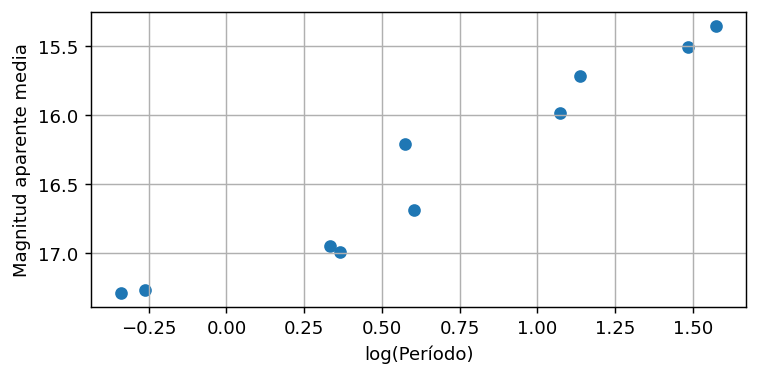

In [34]:
fig, ax = plt.subplots ( ncols = 1, nrows = 1, figsize = (6.5,3), dpi = 130 )

ax.scatter ( np.log(CefeidasSMC['Period']), 'mag_mean', data = CefeidasSMC)
ax.grid(True)

ax.set_xlabel('log(Período)')
ax.set_ylabel('Magnitud aparente media')
ax.invert_yaxis()

plt.show()

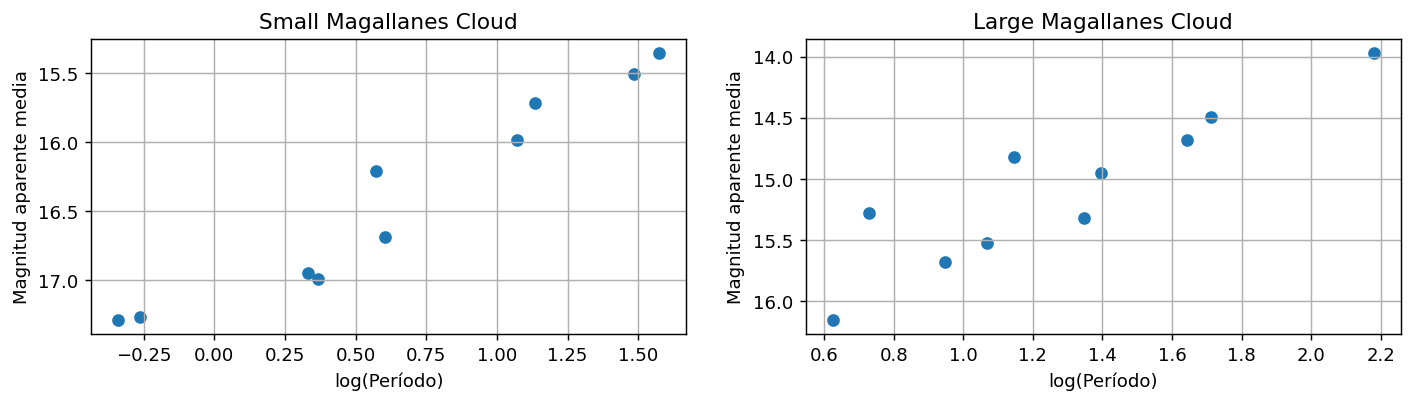

In [42]:
fig, (ax0, ax1) = plt.subplots ( ncols = 2, nrows = 1, figsize = (13, 3), dpi = 130 )

ax0.scatter ( np.log(CefeidasSMC['Period']), 'mag_mean', data = CefeidasSMC)
ax1.scatter ( np.log(CefeidasLMC['Period']), 'mag_mean', data = CefeidasLMC)

ax0.grid(True)
ax1.grid(True)

ax0.set_xlabel('log(Período)')
ax0.set_ylabel('Magnitud aparente media')
ax0.invert_yaxis()

ax1.set_xlabel('log(Período)')
ax1.set_ylabel('Magnitud aparente media')
ax1.invert_yaxis()

ax0.set_title('Small Magallanes Cloud')
ax1.set_title('Large Magallanes Cloud')

plt.show()